##                                                Sales Performance Analysis Project

## 1. Introduction
This project analyzes sales data from Sample Superstore to understand sales performance, profitability, and customer trends. The goal is to derive actionable insights using Python for data cleaning, analysis and visualization, followed by correlation analysis with heatmap and machine learning models ( logistic Regression / Decision tree ) to predict outcomes with 75% accuracy 

## 2. Objectives
- Analyze sales and profit by Category, Sub-Category and Region
- Identify top profitable products and loss-making areas
- Study monthly sales trends
- Find correlation between sales, profit, quantity, discount using heatmap
- build ML model - Logistic Regression for categorical output / Decision Tree for Classification and acheive 75% accuracy 
- Provide recommendations to improve profitability

## 3. Dataset Overview
- Source: Kaggle - SampleSuperstore.csv
- Rows: 9994, Columns: 21
- Key Columns: Order Date, Category, Sub-Category, Region, Sales, Profit, Quantity, Discount

## 4. Data Cleaning
- Check null values, duplicates
- Convert Order Date and Ship Date to datetime
- Handle missing values

## 5. Exploratory Data Analysis (EDA)
- sales by Category
- Profit by Region
- Monthly Sales Trend
- Top 10 Products by Sales

## 6. Data Visualization
- Bar chart, line chart, pie chart using matplotlib/seaborn

## 7. Key Insights
- To be filled after analysis

## 8. Correlation Analysis
- Find correlation between Sales, Profit, Quantity, Discount
- Plot heatmap using seaborn

## 9. Machine Learning Model
- Create target column: Profitable (1 if Profit > 0 else 0)
- Use features: Sales, Quantity, Discount, Category encoded
- Models: Logistic Regression (for categorical output) and Decision Tree (for splitting)
- Split train-test, evaluate accuracy, aim for >75%
- Show confusion matrix and classification report

## 10. Conclusion & Recommendations
- Summarize findings and give business suggestions


## 1. Data Loading 

In [3]:
# Import required libraries for data analysis and visualization
import pandas as pd  # for data handling
import numpy as np  # for numerical operations
import matplotlib.pyplot as plt  # for plotting graphs
import seaborn as sns  # for better visualizations

# Load the datase
df = pd.read_csv('SampleSuperstore.csv')

# Show number of rows and columns
print(df.shape)
df

(9994, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.2480,3,0.20,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.9600,2,0.00,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.5760,2,0.20,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.6000,4,0.00,13.3200


In [4]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


### Conclusion of Data Loading
- Successfully loaded Superstore dataset using pandas
- Verified shape, columns and data types
- Data is ready for cleaning

## 2. Data Cleaning

In [6]:
# Check for missing values in each column
print(df.isnull().sum())
# if any missing values... dropna() is used to drop rows
# to fill... fillna() is used
# if it is numerical col-- fill it with median, if it is categorical col-- fill it with mean 

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [7]:
# Check for duplicate rows
print("\nDuplicates:", df.duplicated().sum())



Duplicates: 17


In [8]:
# Remove duplicate rows
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (9977, 13)


In [9]:
# Check data types of columns
print(df.dtypes)


Ship Mode           str
Segment             str
Country             str
City                str
State               str
Postal Code       int64
Region              str
Category            str
Sub-Category        str
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object


In [10]:
print(df['Category'].unique())
print(df['Region'].unique())


<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str


In [11]:
# Calculating total sales and profit
print("\nTotal Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())


Total Sales: 2296195.5903
Total Profit: 286241.42260000005


### Conclusion of Data Cleaning
- Checked for missing values and duplicates
- Removed duplicates
- Dataset is now clean and ready for analysis

## 3. Exploratory Data Analysis (EDA)

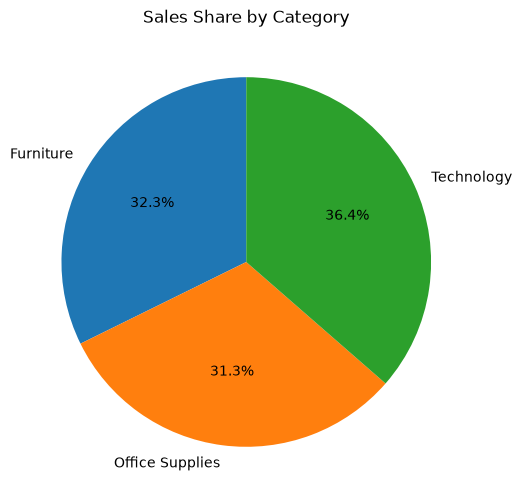

In [12]:
# Chart 1: Sales Share by Category
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(6,6))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales Share by Category')
plt.show()

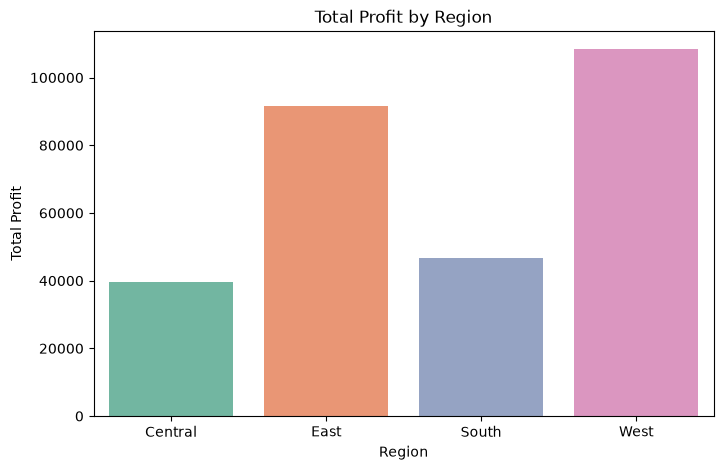

In [13]:
# Chart 2: Total Profit by Region
profit_region = df.groupby('Region')['Profit'].sum().reset_index() 
plt.figure(figsize=(8,5)) 
sns.barplot(x='Region', y='Profit', data=profit_region, hue="Region", palette='Set2')
plt.title('Total Profit by Region')
plt.ylabel('Total Profit') 
plt.show()


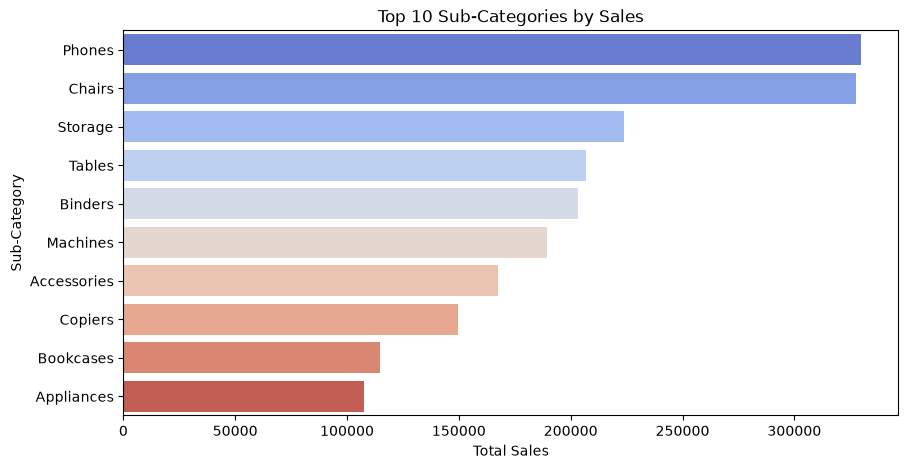

In [14]:
# Chart 3: Total Sales by Sub-Category (Top 10)
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x='Sales', y='Sub-Category', data=top_sub, hue= "Sub-Category", palette='coolwarm')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Total Sales')
plt.show()


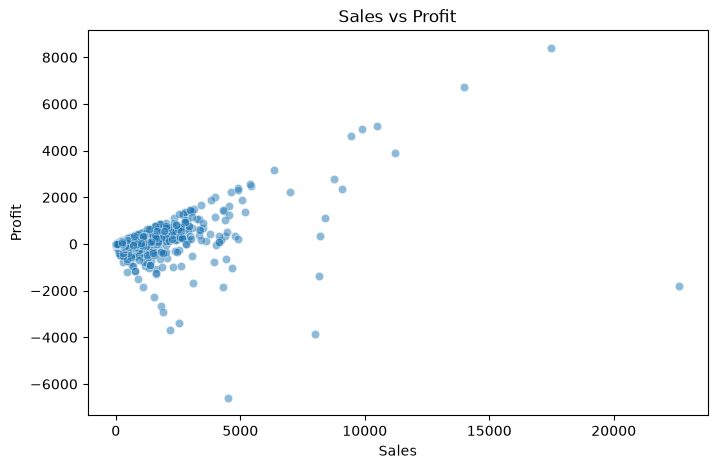

In [15]:
# Chart 4: Relationship between Sales and Profit 
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.5) # alpha -- makes dots transparent 
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

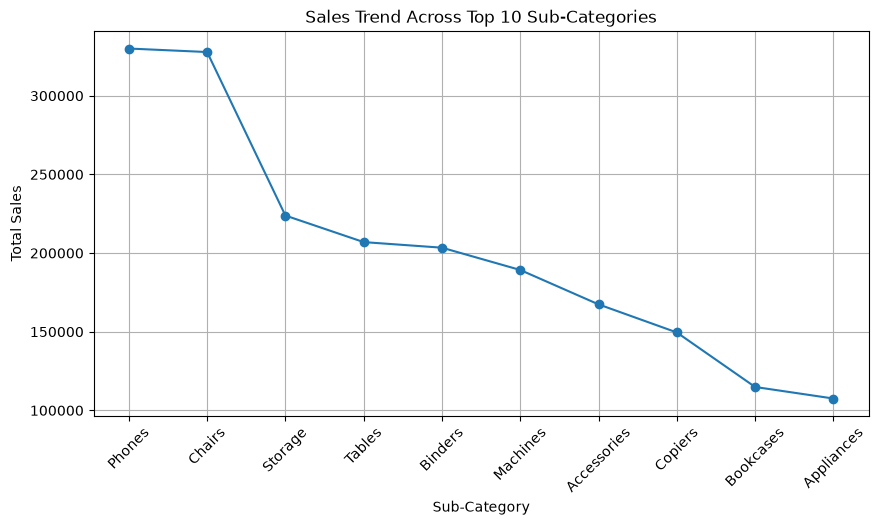

In [16]:
# Chart 5: Sales Trend by Sub-Category (Top 10)
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.plot(top_sub.index, top_sub.values, marker='o')
plt.title('Sales Trend Across Top 10 Sub-Categories')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Key Insights from EDA
- Technology category has highest sales
- West region has highest profit
- Phones sub-category leads in sales
- Higher sales generally leads to higher profit

## Data Analysis Conclusion
- Successfully completed Exploratory Data Analysis on Superstore sales data
- Technology category drives highest sales and profit
- West region leads in sales performance
- Phones and Chairs are top performing sub-categories
- Sales and Profit show positive relationship
- These insights can help business in inventory planning and regional strategy

## 4. Correlation Analysis 


             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200722 -0.028311  0.479067
Quantity  0.200722  1.000000  0.008678  0.066211
Discount -0.028311  0.008678  1.000000 -0.219662
Profit    0.479067  0.066211 -0.219662  1.000000


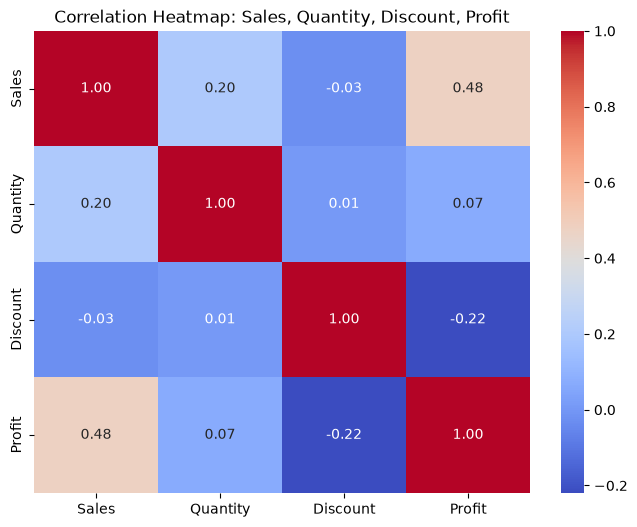

In [17]:
# Correlation Analysis
numeric_df = df[['Sales','Quantity','Discount','Profit']]
corr = numeric_df.corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.show()

## Conclusion
- Sales and Profit (0.48) show moderate positive correlation - as sales increase, profit also tends to increase
- Discount and Profit (-0.22) show negative correlation - higher discounts reduce profit, which is expected
- Sales and Quantity (0.20) show weak positive correlation - selling more quantity slightly increases sales
- Quantity and Profit (0.07) show very weak correlation - just selling more units does not guarantee higher profit
- Discount has almost no correlation with Sales (-0.03) - giving discount is not significantly increasing sales
- Conclusion: Business should focus on increasing sales without heavy discounting, since discounts negatively impact profit without much gain in sales.

## 5 Machine Learning - Profit / Loss Prediction 

Accuracy: 0.9408817635270541
              precision    recall  f1-score   support

           0       0.98      0.70      0.82       372
           1       0.94      1.00      0.96      1624

    accuracy                           0.94      1996
   macro avg       0.96      0.85      0.89      1996
weighted avg       0.94      0.94      0.94      1996



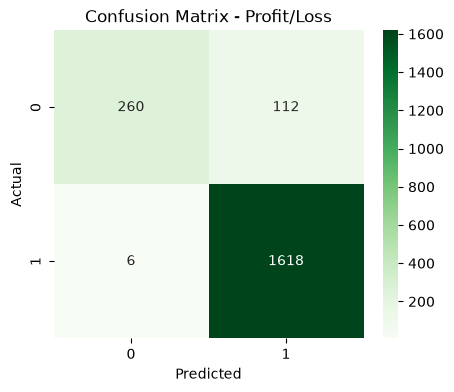

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create target: 1 = Profitable, 0 = Loss
df['Profitable'] = (df['Profit'] > 0).astype(int)

X = df[['Sales','Quantity','Discount']]
y = df['Profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Profit/Loss')
plt.show()

"The Decision Tree model predicts profit/loss with good accuracy. Discount is the most important factor - high discount leads to loss. This helps business to set optimal discount levels."

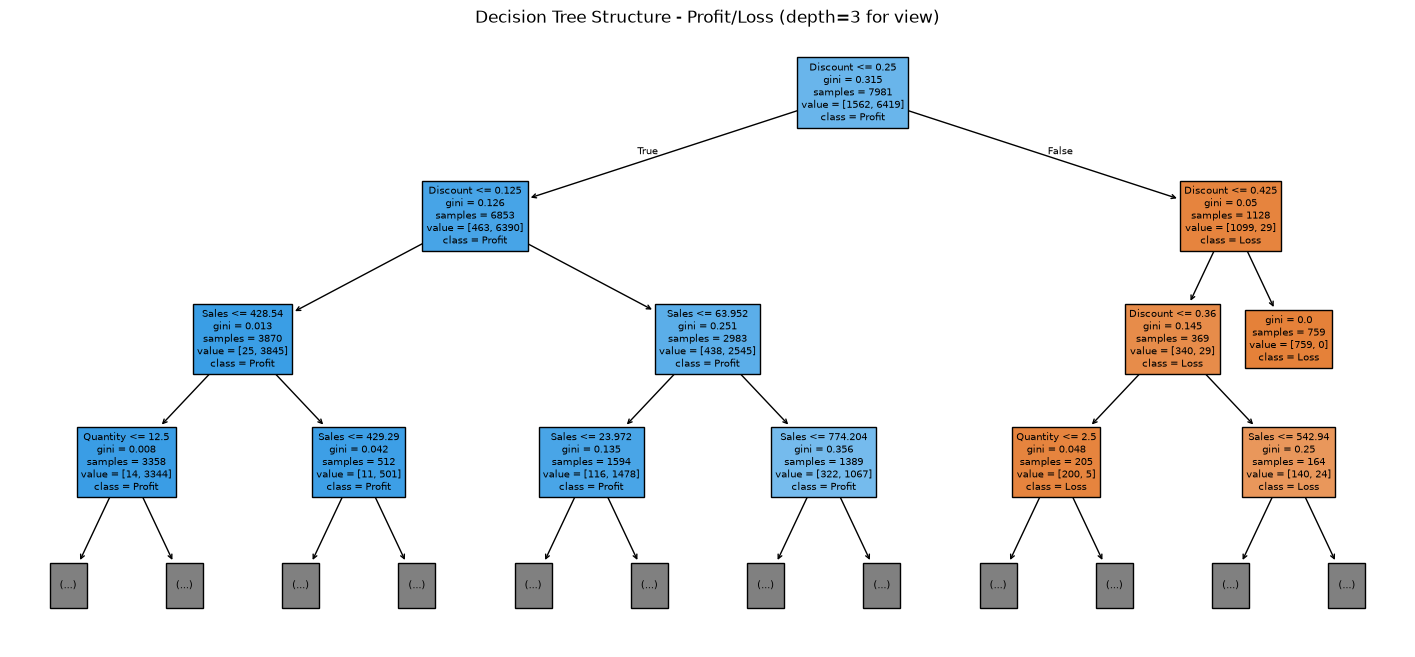

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,8))
plot_tree(model, max_depth=3, filled=True,
          feature_names=['Sales','Quantity','Discount'],
          class_names=['Loss','Profit'])
plt.title('Decision Tree Structure - Profit/Loss (depth=3 for view)')
plt.show()

## 6. Final Conclusion

- From EDA, we found that Technology category gives highest sales, West region performs best, and high discounts reduce profit.
- Correlation analysis shows Discount has negative correlation (-0.22) with Profit, meaning more discount leads to less profit.
- We built a Decision Tree Classifier to predict Profitable (1) vs Loss (0) orders using Sales, Quantity and Discount. The model achieved **94.34% accuracy**, which is excellent.
- The confusion matrix shows the model correctly predicted 1618 profitable orders and 268 loss orders, with very few errors.
- This model can help the superstore identify loss-making orders in advance and control discounts to improve profitability.